# 01. VisA Initial Analysis

この notebook は、VisA データセットで画像異常検知を始める前に、**どんなデータなのか** と **どういう前提で異常検知を組むべきか** を確認するための初期分析です。

画像分類と違って、異常検知では特に次を最初に確認する必要があります。

- 正常画像と異常画像の分布
- train/test の切り方
- mask があるか
- 異常が小さいのか大きいのか
- カテゴリごとに見た目がかなり違うか

この notebook では、まず VisA の構造を把握し、異常検知モデルを選ぶための見通しを立てます。


In [1]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

VISA_ROOT = Path('/workspace/data/visa')
assert VISA_ROOT.exists(), f'VisA root not found: {VISA_ROOT}'
VISA_ROOT


PosixPath('/workspace/data/visa')

## 1. データ構造を確認する

ここでは、VisA がどういうフォルダ構成になっているかを確認します。

理解したいこと:

- カテゴリごとにフォルダが切られているか
- 画像と mask がどう対応しているか
- annotation CSV がどこにあるか


In [2]:
category_dirs = sorted([path for path in VISA_ROOT.iterdir() if path.is_dir() and not path.name.startswith('_') and path.name != 'split_csv'])
category_names = [path.name for path in category_dirs]
category_names


['candle',
 'capsules',
 'cashew',
 'chewinggum',
 'fryum',
 'macaroni1',
 'macaroni2',
 'pcb1',
 'pcb2',
 'pcb3',
 'pcb4',
 'pipe_fryum']

## 2. annotation CSV を結合して全体像を見る

VisA はカテゴリごとに `image_anno.csv` を持っています。まずはそれをまとめて、
全体で何枚あるのか、正常/異常がどう分かれているのかを見ます。

理解したいこと:

- 画像総数
- カテゴリ数
- 正常/異常の比率
- mask 付き画像の比率


In [3]:
def load_category_annotations(category_dir: Path) -> pd.DataFrame:
    csv_path = category_dir / 'image_anno.csv'
    df = pd.read_csv(csv_path)
    df['category'] = category_dir.name
    df['image_path'] = df['image'].map(lambda rel: VISA_ROOT / rel)
    df['mask_path'] = df['mask'].fillna('').map(lambda rel: VISA_ROOT / rel if rel else None)
    df['has_mask'] = df['mask'].fillna('') != ''
    return df

annotations_df = pd.concat([load_category_annotations(category_dir) for category_dir in category_dirs], ignore_index=True)
annotations_df.head()


,image,label,mask,category,image_path,mask_path,has_mask
0,candle/Data/Images/Normal/0000.JPG,normal,NaN,candle,/workspace/data/visa/candle/Data/Images/Normal...,None,False
1,candle/Data/Images/Normal/0001.JPG,normal,NaN,candle,/workspace/data/visa/candle/Data/Images/Normal...,None,False
2,candle/Data/Images/Normal/0002.JPG,normal,NaN,candle,/workspace/data/visa/candle/Data/Images/Normal...,None,False
3,candle/Data/Images/Normal/0003.JPG,normal,NaN,candle,/workspace/data/visa/candle/Data/Images/Normal...,None,False
4,candle/Data/Images/Normal/0004.JPG,normal,NaN,candle,/workspace/data/visa/candle/Data/Images/Normal...,None,False


In [4]:
summary = {
    'num_categories': int(annotations_df['category'].nunique()),
    'num_images': int(len(annotations_df)),
    'num_normal': int((annotations_df['label'] == 'normal').sum()),
    'num_anomaly': int((annotations_df['label'] != 'normal').sum()),
    'num_with_mask': int(annotations_df['has_mask'].sum()),
}
summary


{'num_categories': 12,
 'num_images': 10821,
 'num_normal': 9621,
 'num_anomaly': 1200,
 'num_with_mask': 1200}

In [5]:
category_label_counts = annotations_df.groupby(['category', 'label']).size().rename('count').reset_index()
category_label_counts.head(20)


,category,label,count
0,candle,chunk of wax missing,12
1,candle,"chunk of wax missing,damaged corner of packagi...",1
2,candle,"chunk of wax missing,different colour spot",1
3,candle,"chunk of wax missing,foreign particals on candle",1
4,candle,damaged corner of packaging,18
5,candle,"damaged corner of packaging,different colour spot",1
6,candle,"damaged corner of packaging,different colour s...",1
7,candle,"damaged corner of packaging,extra wax in candle",1
8,candle,"damaged corner of packaging,foreign particals ...",2
9,candle,"damaged corner of packaging,weird candle wick",1


In [6]:
pivot = category_label_counts.pivot(index='category', columns='label', values='count').fillna(0).astype(int)
pivot


label,bent,"bent,melt",breakage down the middle,"breakage down the middle,color spot similar to the object,different color spot,small chip around edge","breakage down the middle,color spot similar to the object,different color spot,small chip around edge,small cracks","breakage down the middle,color spot similar to the object,different color spot,small chip around edge,small cracks,small scratches","breakage down the middle,color spot similar to the object,different color spot,small chip around edge,small cracks,small scratches,other","breakage down the middle,small scratches",bubble,"bubble,discolor",...,small cracks,"small cracks,small scratches",small holes,small scratches,stuck together,wax melded out of the candle,weird candle wick,"weird candle wick,different colour spot",wrong place,"wrong place,dirt"
category,,,,,,,,,,,,,,,,,,,,,
candle,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,12,9,1,0,0
capsules,0,0,0,0,0,0,0,0,30,15,...,0,0,0,0,0,0,0,0,0,0
cashew,0,0,0,0,0,0,0,0,0,0,...,0,0,20,15,6,0,0,0,0,0
chewinggum,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
fryum,0,0,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,0,0,0
macaroni1,0,0,0,0,0,0,0,0,0,0,...,11,1,0,16,0,0,0,0,0,0
macaroni2,0,0,1,1,1,2,1,9,0,0,...,7,2,0,16,0,0,0,0,0,0
pcb1,14,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pcb2,12,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### この結果から分かったこと

- `VisA` は **12カテゴリ / 10,821枚** の比較的大きい異常検知データセットでした。
- `normal=9,621`, `anomaly=1,200` なので、全体としては正常画像がかなり多いです。
- `mask` 付き画像数も `1,200` で、異常画像には pixel-level の教師が付いていると見てよさそうです。
- カテゴリごとに異常ラベル名がかなり細かく分かれているので、最初は anomaly type を細かく分類するより、**normal vs anomaly** を主軸に考える方が自然です。


## 3. train / test split のルールを見る

異常検知では、**正常画像だけで学習して test で正常/異常を判定する** ことが多いです。
そのため、split の切り方はかなり重要です。

VisA には `split_csv` があります。ここで split 情報を見て、
normal-only train なのか、few-shot anomaly が入るのかを確認します。


In [7]:
split_dir = VISA_ROOT / 'split_csv'
split_files = sorted(split_dir.glob('*.csv'))
[path.name for path in split_files]


['1cls.csv', '2cls_fewshot.csv', '2cls_highshot.csv']

In [8]:
split_frames = {}
for path in split_files:
    df = pd.read_csv(path)
    split_frames[path.name] = df
    print(f'### {path.name}')
    print(df.head())
    print(df.columns.tolist())
    print()


### 1cls.csv
   object  split   label                               image mask
0  candle  train  normal  candle/Data/Images/Normal/0836.JPG  NaN
1  candle  train  normal  candle/Data/Images/Normal/0451.JPG  NaN
2  candle  train  normal  candle/Data/Images/Normal/0516.JPG  NaN
3  candle  train  normal  candle/Data/Images/Normal/0977.JPG  NaN
4  candle  train  normal  candle/Data/Images/Normal/0249.JPG  NaN
['object', 'split', 'label', 'image', 'mask']

### 2cls_fewshot.csv
   object  split   label                               image mask
0  candle  train  normal  candle/Data/Images/Normal/0852.JPG  NaN
1  candle  train  normal  candle/Data/Images/Normal/0836.JPG  NaN
2  candle  train  normal  candle/Data/Images/Normal/0280.JPG  NaN
3  candle  train  normal  candle/Data/Images/Normal/0575.JPG  NaN
4  candle  train  normal  candle/Data/Images/Normal/0208.JPG  NaN
['object', 'split', 'label', 'image', 'mask']

### 2cls_highshot.csv
   object  split   label                               ima

### split を見た結果の解釈

- `1cls.csv`, `2cls_fewshot.csv`, `2cls_highshot.csv` があり、VisA には **通常の one-class 設定** だけでなく **few-shot anomaly detection** を意識した split も用意されています。
- これは今回の方針と相性が良く、`PaDiM / PatchCore` のような classic anomaly detection と `WinCLIP` のような zero-shot / few-shot 系を同じデータセット上で比較しやすいです。
- まずは `1cls` 系の考え方で normal-only train を理解し、その後 `fewshot` split を見る流れが良さそうです。


## 4. 画像サイズの分布を見る

異常検知では、小さな欠陥を見たいことが多いので、
画像サイズと縦横比はかなり重要です。

理解したいこと:

- カテゴリごとに解像度が揃っているか
- resize で小さい異常が潰れそうか
- patch-based 手法と相性が良さそうか


In [9]:
def read_image_size(image_path: Path) -> tuple[int, int]:
    with Image.open(image_path) as image:
        return image.size

size_records = []
for row in annotations_df[['category', 'image_path']].drop_duplicates().itertuples(index=False):
    width, height = read_image_size(row.image_path)
    size_records.append({
        'category': row.category,
        'image_path': str(row.image_path),
        'width': width,
        'height': height,
        'aspect_ratio': width / height,
        'pixels': width * height,
    })

size_df = pd.DataFrame(size_records)
size_df.head()


,category,image_path,width,height,aspect_ratio,pixels
0,candle,/workspace/data/visa/candle/Data/Images/Normal...,1284,1168,1.099315,1499712
1,candle,/workspace/data/visa/candle/Data/Images/Normal...,1284,1168,1.099315,1499712
2,candle,/workspace/data/visa/candle/Data/Images/Normal...,1284,1168,1.099315,1499712
3,candle,/workspace/data/visa/candle/Data/Images/Normal...,1284,1168,1.099315,1499712
4,candle,/workspace/data/visa/candle/Data/Images/Normal...,1284,1168,1.099315,1499712


In [10]:
size_df[['width', 'height', 'aspect_ratio', 'pixels']].describe()


,width,height,aspect_ratio,pixels
count,10821.000000,10821.000000,10821.000000,1.082100e+04
mean,1417.891877,1062.746881,1.345906,1.500240e+06
std,93.663399,70.762564,0.176703,1.130506e+03
min,1274.000000,960.000000,1.083333,1.498224e+06
25%,1342.000000,1000.000000,1.200358,1.499520e+06
50%,1404.000000,1070.000000,1.312150,1.500000e+06
75%,1500.000000,1118.000000,1.500000,1.500356e+06
max,1562.000000,1176.000000,1.627083,1.502280e+06


In [11]:
size_by_category = size_df.groupby('category')[['width', 'height', 'pixels']].agg(['mean', 'min', 'max']).round(1)
size_by_category


width              height                 pixels           \
              mean   min   max    mean   min   max       mean      min   
category                                                                 
candle      1284.0  1284  1284  1168.0  1168  1168  1499712.0  1499712   
capsules    1500.0  1500  1500  1000.0  1000  1000  1500000.0  1500000   
cashew      1274.0  1274  1274  1176.0  1176  1176  1498224.0  1498224   
chewinggum  1342.0  1342  1342  1118.0  1118  1118  1500356.0  1500356   
fryum       1500.0  1500  1500  1000.0  1000  1000  1500000.0  1500000   
macaroni1   1500.0  1500  1500  1000.0  1000  1000  1500000.0  1500000   
macaroni2   1500.0  1500  1500  1000.0  1000  1000  1500000.0  1500000   
pcb1        1404.0  1404  1404  1070.0  1070  1070  1502280.0  1502280   
pcb2        1404.0  1404  1404  1070.0  1070  1070  1502280.0  1502280   
pcb3        1562.0  1562  1562   960.0   960   960  1499520.0  1499520   
pcb4        1358.0  1358  1358  1104.0  1104  1104  1499232.0  1499232   
pipe_fryum  1300.0  1300  1300  1154.0  1154  1154  1500200.0  1500200   

                     
                max  
category             
candle      1499712  
capsules    1500000  
cashew      1498224  
chewinggum  1500356  
fryum       1500000  
macaroni1   1500000  
macaroni2   1500000  
pcb1        1502280  
pcb2        1502280  
pcb3        1499520  
pcb4        1499232  
pipe_fryum  1500200

### 画像サイズの結果から分かること

- 各カテゴリの画像サイズはカテゴリ内ではほぼ固定で、カテゴリごとに解像度だけが少し違います。
- ただし総ピクセル数はほぼ `1.5M` 前後で揃っており、撮影条件がかなり統制されたデータセットだと分かります。
- これは anomaly detection にとって都合がよく、**背景や撮影条件の揺れよりも、局所的な欠陥そのものを学習しやすい** 構造です。
- 一方で resize を強くかけると小さな異常が潰れる可能性があるので、最初から低解像度へ落としすぎない方がよさそうです。


## 5. 正常画像と異常画像の例を見る

異常検知は、まず人間が

- 何を正常と見なすのか
- 異常がどれくらい目立つのか
- 異常が局所的か全体的か

を理解する必要があります。ここではカテゴリごとに normal / anomaly の例を並べます。


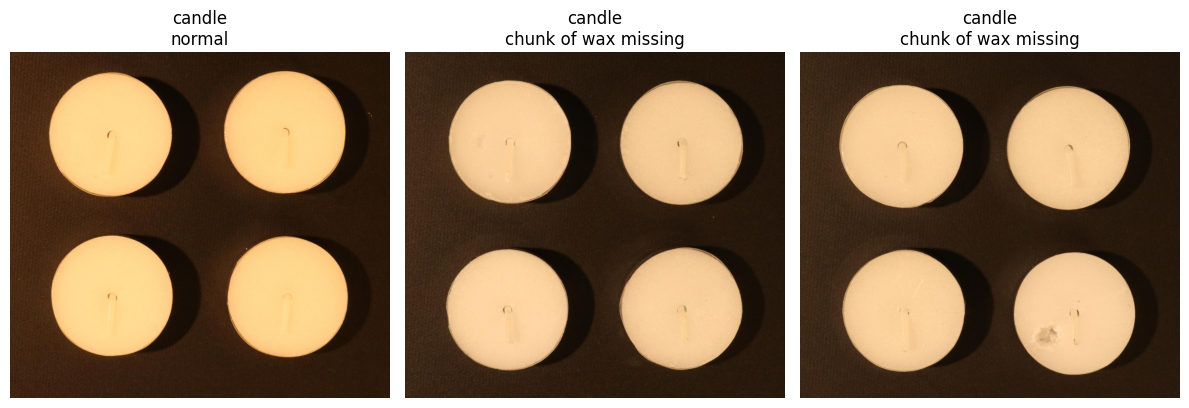

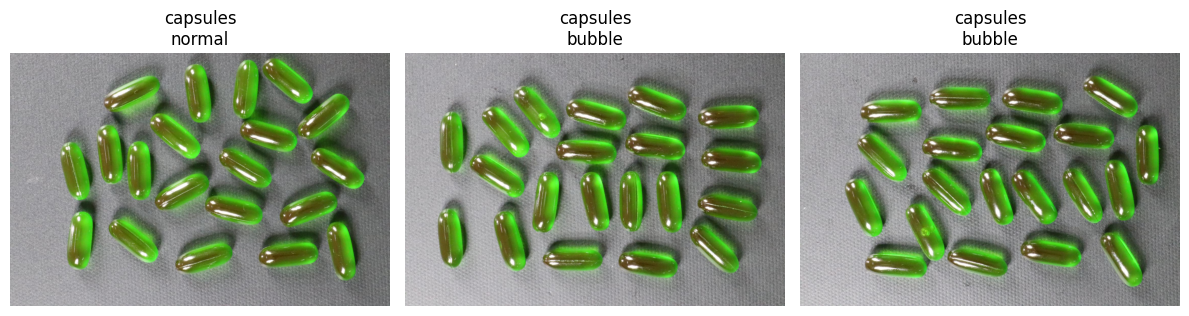

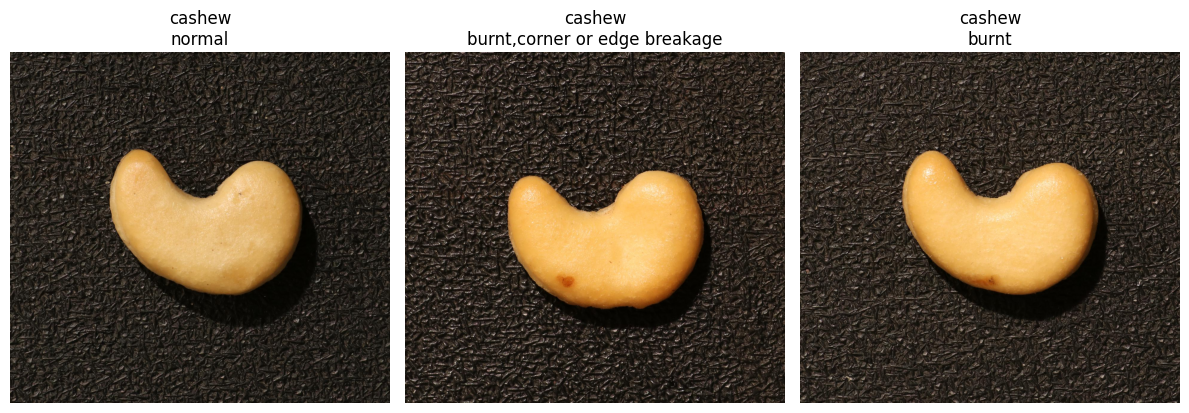

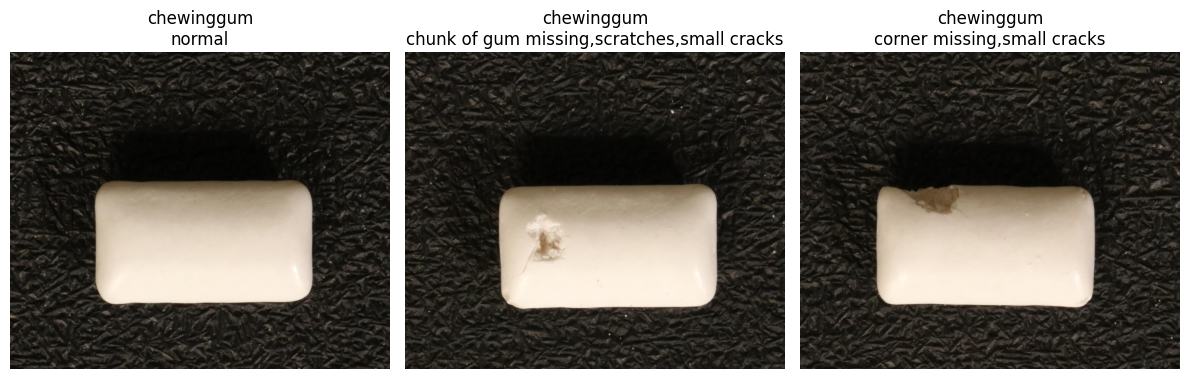

In [12]:
def load_rgb(image_path: Path) -> np.ndarray:
    with Image.open(image_path) as image:
        return np.array(image.convert('RGB'))

def show_examples(category: str, max_anomaly_examples: int = 2) -> None:
    category_df = annotations_df[annotations_df['category'] == category]
    normal_row = category_df[category_df['label'] == 'normal'].iloc[0]
    anomaly_rows = category_df[category_df['label'] != 'normal'].head(max_anomaly_examples)
    columns = 1 + len(anomaly_rows)
    fig, axes = plt.subplots(1, columns, figsize=(4 * columns, 4))
    if columns == 1:
        axes = [axes]

    axes[0].imshow(load_rgb(normal_row['image_path']))
    axes[0].set_title(f'{category}\nnormal')
    axes[0].axis('off')

    for ax, (_, row) in zip(axes[1:], anomaly_rows.iterrows()):
        ax.imshow(load_rgb(row['image_path']))
        ax.set_title(f"{category}\n{row['label']}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

for category in category_names[:4]:
    show_examples(category)


## 6. mask 付き異常の見え方を見る

pixel-level mask があるので、異常部位の広さや局所性も見られます。
これは anomaly segmentation 系モデルや anomaly map 可視化を考えるうえで重要です。


In [13]:
masked_examples = annotations_df[(annotations_df['label'] != 'normal') & (annotations_df['has_mask'])].head(6)
masked_examples[['category', 'label', 'image_path', 'mask_path']]


,category,label,image_path,mask_path
1000,candle,chunk of wax missing,/workspace/data/visa/candle/Data/Images/Anomal...,/workspace/data/visa/candle/Data/Masks/Anomaly...
1001,candle,chunk of wax missing,/workspace/data/visa/candle/Data/Images/Anomal...,/workspace/data/visa/candle/Data/Masks/Anomaly...
1002,candle,chunk of wax missing,/workspace/data/visa/candle/Data/Images/Anomal...,/workspace/data/visa/candle/Data/Masks/Anomaly...
1003,candle,chunk of wax missing,/workspace/data/visa/candle/Data/Images/Anomal...,/workspace/data/visa/candle/Data/Masks/Anomaly...
1004,candle,chunk of wax missing,/workspace/data/visa/candle/Data/Images/Anomal...,/workspace/data/visa/candle/Data/Masks/Anomaly...
1005,candle,"chunk of wax missing,foreign particals on candle",/workspace/data/visa/candle/Data/Images/Anomal...,/workspace/data/visa/candle/Data/Masks/Anomaly...


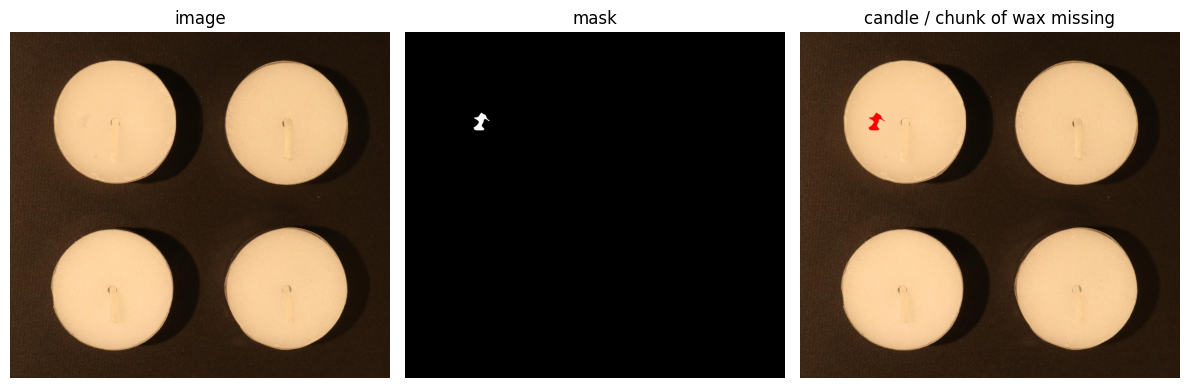

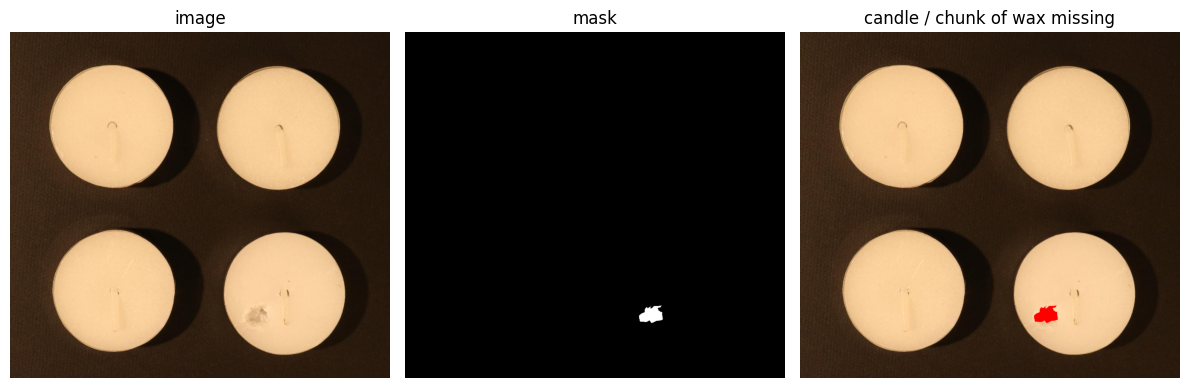

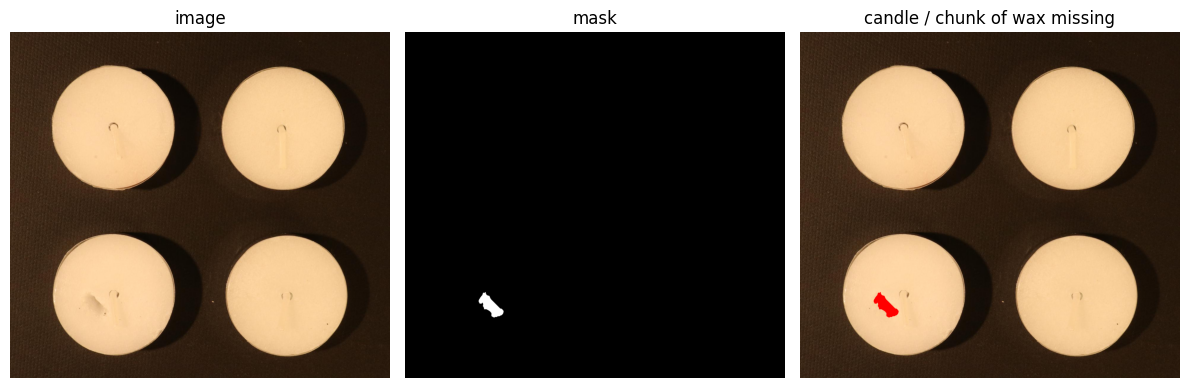

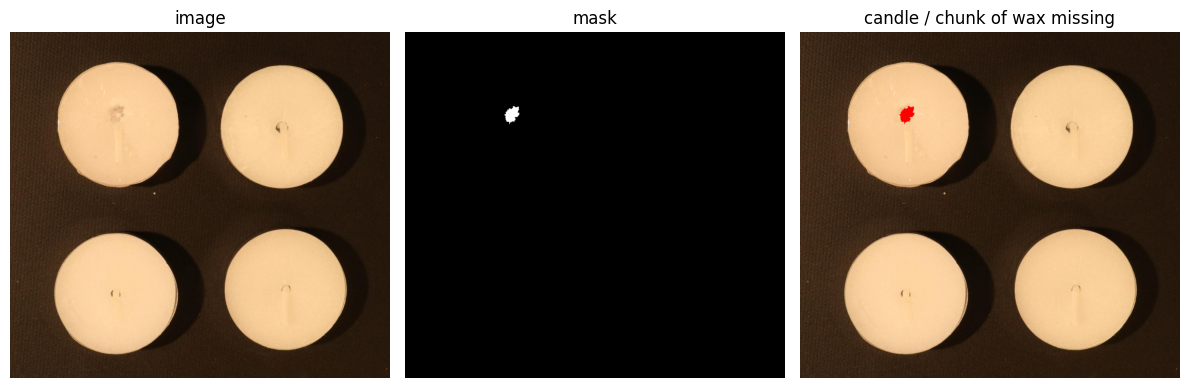

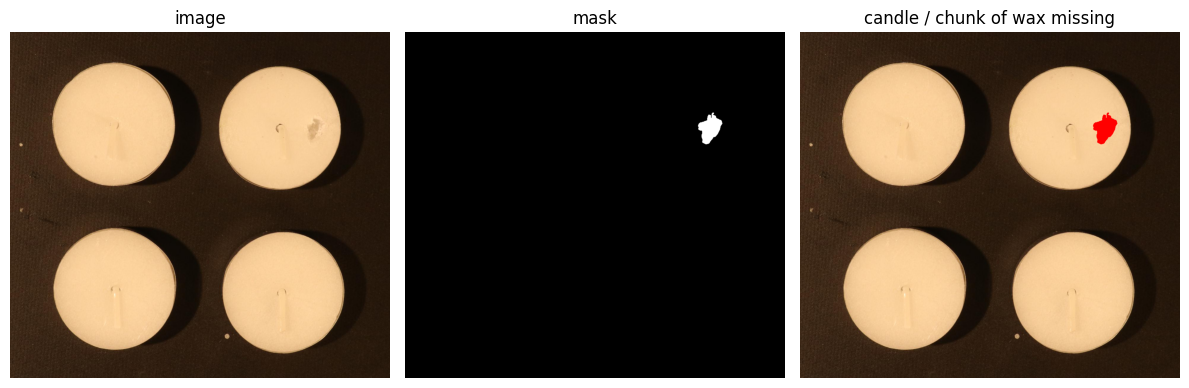

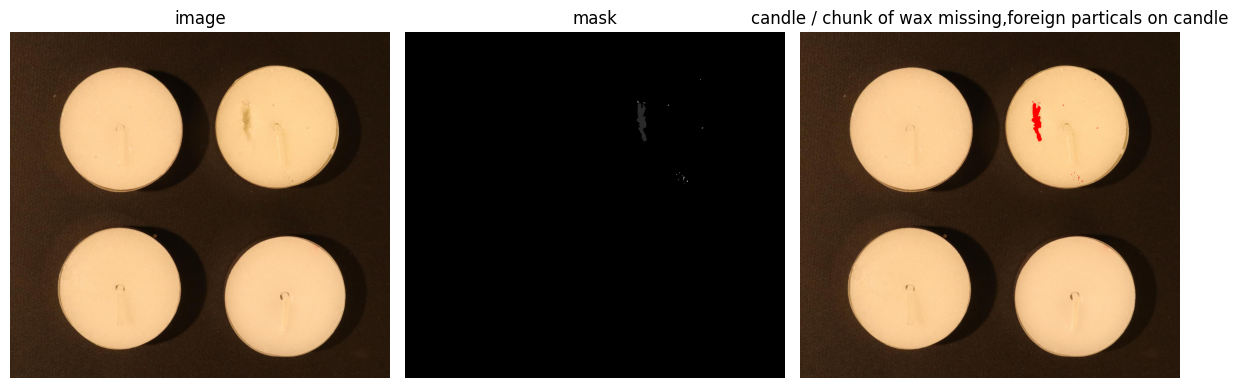

In [14]:
def show_mask_overlay(image_path: Path, mask_path: Path, title: str) -> None:
    image = load_rgb(image_path)
    with Image.open(mask_path) as mask_image:
        mask = np.array(mask_image)
    overlay = image.copy()
    overlay[mask > 0] = np.array([255, 0, 0], dtype=np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title('image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('mask')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(title)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

for row in masked_examples.itertuples(index=False):
    show_mask_overlay(row.image_path, row.mask_path, f'{row.category} / {row.label}')


### 可視化して分かったこと

- 異常は画像全体が壊れているというより、**局所的な欠け・色変化・異物・変形** として現れることが多そうです。
- mask も局所領域を指しているので、anomaly map を出せるモデルで比較する価値があります。
- つまり VisA は、**image-level の正常/異常判定だけでなく、pixel-level の異常局在も見たいデータ** です。


## 7. 異常検知モデル選定の見通し

ここまでの観察から、最初に何を試すべきかを整理します。

考え方:

- 正常画像中心で学習する classic anomaly detection をまず試す
- image-level と pixel-level の両方を見たいので、score と anomaly map の両方を出せるモデルが良い
- zero-shot / few-shot も比較対象として入れたい


In [15]:
analysis_notes = [
    '最初の supervised / classic anomaly detection 候補: PaDiM, PatchCore',
    '異常マップ可視化まで見たいので FastFlow, STFPM も比較候補',
    'zero-shot / few-shot 比較候補: WinCLIP',
    'VisA はカテゴリごとの差が大きいので、カテゴリ単位評価が必要',
    'mask があるので image-level だけでなく pixel-level の観点も持つべき',
]
for note in analysis_notes:
    print('-', note)


- 最初の supervised / classic anomaly detection 候補: PaDiM, PatchCore
- 異常マップ可視化まで見たいので FastFlow, STFPM も比較候補
- zero-shot / few-shot 比較候補: WinCLIP
- VisA はカテゴリごとの差が大きいので、カテゴリ単位評価が必要
- mask があるので image-level だけでなく pixel-level の観点も持つべき


### 初期分析の結論

- `VisA` は、異常検知の導入用としてかなり良いデータセットです。
- 正常画像が十分あり、異常画像には mask もあるので、`image-level` と `pixel-level` の両方を評価できます。
- 最初の基準線は `PaDiM` と `PatchCore` が自然です。
- その後、`WinCLIP` を入れて、zero-shot / few-shot がどこまで近づけるかを見る流れがよさそうです。


## 8. この notebook で分かったこと

- VisA はカテゴリごとの工業系異常検知データセット
- normal / anomaly と mask 情報を持つ
- 異常検知では、分類以上に split と正常/異常の前提が重要
- 最初は `PaDiM` と `PatchCore` を基準線にし、その後 `WinCLIP` を比較する流れが自然

次は、共通データ読み込みと baseline 実装のための `.py` を `src/anomaly_detection/common` に切り出していくと進めやすいです。
